In [3]:
import pandas as pd
import glob
import numpy as np
from evcouplings.compare import DistanceMap
from copy import deepcopy
from scipy.stats import ks_2samp
import os
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from evcouplings.visualize.pymol import (
    pymol_pair_lines, pymol_mapping
)
from sklearn.metrics import roc_curve
from sklearn import metrics

import seaborn as sns

# Combine the results for each indiviudal run

In [4]:
def get_scores_above_quantile(scores, quantile_cutoff):
    score_cutoff = scores.G_score.quantile(quantile_cutoff)
    return scores.query("G_score >= @score_cutoff")

def get_residue_indices(scores, dm):
    # Get the index of each residue in the score table in the distance map
    dm.residues_i = dm.residues_i.reset_index(drop=True)
    
    residues_to_find = scores.residue.values
    
    dm.residues_i.id = dm.residues_i.id.astype(int)
    
    subset = dm.residues_i.query("id in @residues_to_find")
    
    return subset

def inter_quantile_distances(scores, dm, quantile_cutoff):
    quantile_scores = get_scores_above_quantile(scores, quantile_cutoff)
    subset = get_residue_indices(quantile_scores, dm)
    subset_matrix= dm.dist_matrix[:, np.array(subset.index)][np.array(subset.index), :]
    flat_subset = subset_matrix.flatten()
    flat_subset = flat_subset[flat_subset > 0]

    return flat_subset




In [5]:
# import time

# positive_controls = pd.read_csv("controls/positive_control_set_random_paired.csv", index_col=0)
# positive_controls["label"] = 1
# output_path = "controls/positive_controls_paired//"
# columns_to_create = ["num_shuffles", "max_pvalue", "ks_test_num_significant_0p01", 
#                      "selected_pvalue", "median_pvalue", "min_pvalue", "distance_top_pair"]
# for i in columns_to_create:
#     positive_controls[i]= np.nan
# NUM_SHUFFLES=10000 

# for idx, row in positive_controls.iterrows():
#     time0 = time.time()
#     uid = row.id
#     rv = row.rv
#     entry = row.Entry
#     print(uid, rv, entry)
#     try:
#         G_scores = pd.read_csv(f"{output_path}/{uid}/G_scores.csv", index_col=0)
#         #shuffle_table = pd.read_csv(f"{output_path}/{uid}/random_GeO_iterations_{NUM_SHUFFLES}.csv", index_col=0)
#         result_table = pd.read_csv(f"{output_path}/{uid}/random_GeO_pvalues_{NUM_SHUFFLES}.csv.gz", compression="gzip")
#         result_table_full = pd.read_csv(f"{output_path}/{uid}/random_GeO_full_distribution_{NUM_SHUFFLES}.csv")

#     except:
#         continue
        
# #    values = shuffle_table.iloc[:,1::].values.flatten()
#     positive_controls.loc[idx, "num_shuffles"] = len(result_table)
#     positive_controls.loc[idx, "max_pvalue"] = result_table.pvalue.max()
#     positive_controls.loc[idx, "min_pvalue"] = result_table.pvalue.min()
#     positive_controls.loc[idx, "median_pvalue"] = np.nanmedian(result_table.pvalue)
#     positive_controls.loc[idx, "mean_pvalue"] = np.nanmean(result_table.pvalue)
#     positive_controls.loc[idx, "ks_test_num_significant_0p01"] = len(result_table.query("pvalue < 0.01"))
#     positive_controls.loc[idx, "selected_pvalue"] = result_table.loc[np.random.randint(0, len(result_table)+1), "pvalue"]
    
    
#     # acquire the distances between the top 2 most mutated sites
#     mutations = pd.read_csv(f"{output_path}/{uid}/mutations_analyzed.csv", index_col=0)
    
#     dm = DistanceMap.from_file(f"filtered_distmaps/{entry}")
#     positive_controls.loc[idx, "distance_top_pair"] = dm.dist(mutations.residue.iloc[0], mutations.residue.iloc[1])
#     positive_controls.loc[idx, "distance_90_percentile"] = np.median(inter_quantile_distances(G_scores, dm, .9))
    
#     positive_controls.loc[idx, "max_GeO_greater"] = result_table_full.max_GeO_greater.values[0]
#     positive_controls.loc[idx, "mean_GeO_greater"] = result_table_full.mean_GeO_greater.values[0]
#     positive_controls.loc[idx, "min_GeO_greater"] = result_table_full.min_GeO_greater.values[0]


# positive_controls

In [6]:
# import time

# negative_controls = pd.read_csv("controls/negative_controls_random_set.csv", index_col=0)
# negative_controls["label"] = 0
# output_path = "controls/negative_controls_random/"
# columns_to_create = ["num_shuffles", "max_pvalue", "ks_test_num_significant_0p01", 
#                      "selected_pvalue", "median_pvalue", "min_pvalue", "distance_top_pair"]
# for i in columns_to_create:
#     negative_controls[i]= np.nan
# NUM_SHUFFLES=10000 

# for idx, row in negative_controls.iterrows():
#     time0 = time.time()
#     uid = row.id
#     rv = row.rv
#     entry = row.Entry
#     #print(uid, rv, entry)
#     try:
#         G_scores = pd.read_csv(f"{output_path}/{uid}/G_scores.csv", index_col=0)
#         #shuffle_table = pd.read_csv(f"{output_path}/{uid}/random_GeO_iterations_{NUM_SHUFFLES}.csv", index_col=0)
#         result_table = pd.read_csv(f"{output_path}/{uid}/random_GeO_pvalues_{NUM_SHUFFLES}.csv.gz", compression="gzip")
#         result_table_full = pd.read_csv(f"{output_path}/{uid}/random_GeO_full_distribution_{NUM_SHUFFLES}.csv")

#         if not "max_GeO_greater" in result_table_full.columns:
#             continue
#     except:
#         continue
        

# #    values = shuffle_table.iloc[:,1::].values.flatten()
#     negative_controls.loc[idx, "num_shuffles"] = len(result_table)
#     negative_controls.loc[idx, "max_pvalue"] = result_table.pvalue.max()
#     negative_controls.loc[idx, "min_pvalue"] = result_table.pvalue.min()
#     negative_controls.loc[idx, "mean_pvalue"] = np.nanmean(result_table.pvalue)
#     negative_controls.loc[idx, "median_pvalue"] = np.nanmedian(result_table.pvalue)
#     negative_controls.loc[idx, "ks_test_num_significant_0p01"] = len(result_table.query("pvalue < 0.01"))
#     negative_controls.loc[idx, "selected_pvalue"] = result_table.loc[np.random.randint(0, len(result_table)+1), "pvalue"]
    
#         # acquire the distances between the top 2 most mutated sites
#     mutations = pd.read_csv(f"{output_path}/{uid}/mutations_analyzed.csv", index_col=0)
    
#     dm = DistanceMap.from_file(f"filtered_distmaps/{entry}")
#     negative_controls.loc[idx, "distance_top_pair"] = dm.dist(mutations.residue.iloc[0], mutations.residue.iloc[1])
#     negative_controls.loc[idx, "distance_90_percentile"] = np.median(inter_quantile_distances(G_scores, dm, .9))
#     negative_controls.loc[idx, "max_GeO"] = G_scores.G_score.max()
    
#     negative_controls.loc[idx, "max_GeO_greater"] = result_table_full.max_GeO_greater.values[0]
#     negative_controls.loc[idx, "mean_GeO_greater"] = result_table_full.mean_GeO_greater.values[0]
#     negative_controls.loc[idx, "min_GeO_greater"] = result_table_full.min_GeO_greater.values[0]

# negative_controls

In [7]:
# positive_controls["set"] = "positive"
# negative_controls["set"] = "negative"

# data = pd.concat([positive_controls, negative_controls])
# data.to_csv("summary_data/controls_10000iterations_pvalues_NOTPAIRED.csv")




In [8]:
data = pd.read_csv("summary_data/controls_10000iterations_pvalues_NOTPAIRED.csv")

In [9]:
data

,Unnamed: 0,id,uid,iteration,Entry,rv,label,num_shuffles,max_pvalue,ks_test_num_significant_0p01,...,median_pvalue,min_pvalue,distance_top_pair,mean_pvalue,distance_90_percentile,max_GeO_greater,mean_GeO_greater,min_GeO_greater,set,max_GeO
0,0,RPOB_MYCTU_0,RPOB_MYCTU,0,P9WGY9,Rv0667,1,10000.0,0.619650,9932.0,...,2.021952e-63,1.098900e-306,5.074114,0.000553,14.391684,8712.0,10000.0,9974.0,positive,NaN
1,1,RPOB_MYCTU_1,RPOB_MYCTU,1,P9WGY9,Rv0667,1,10000.0,0.550012,9928.0,...,2.021952e-63,0.000000e+00,5.074114,0.000599,14.186815,9001.0,10000.0,9876.0,positive,NaN
2,2,RPOB_MYCTU_2,RPOB_MYCTU,2,P9WGY9,Rv0667,1,10000.0,0.619650,9950.0,...,1.731536e-57,2.256743e-303,5.074114,0.000411,14.041261,9221.0,10000.0,9464.0,positive,NaN
3,3,RPOB_MYCTU_3,RPOB_MYCTU,3,P9WGY9,Rv0667,1,10000.0,0.335959,9938.0,...,3.395645e-54,1.098900e-306,5.074114,0.000401,14.391302,9165.0,10000.0,9893.0,positive,NaN
4,4,RPOB_MYCTU_4,RPOB_MYCTU,4,P9WGY9,Rv0667,1,10000.0,0.725216,9935.0,...,1.061746e-60,0.000000e+00,5.074114,0.000504,14.211906,8730.0,10000.0,9691.0,positive,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,895,RS12_MYCTU_95,RS12_MYCTU,95,P9WH63,Rv0682,0,10000.0,1.000000,579.0,...,3.992468e-01,8.124107e-09,26.360006,0.422952,17.781191,7371.0,6159.0,8652.0,negative,3.075370
1796,896,RS12_MYCTU_96,RS12_MYCTU,96,P9WH63,Rv0682,0,10000.0,0.998615,945.0,...,1.874196e-01,1.912832e-07,17.752544,0.278103,11.459142,6685.0,3141.0,1378.0,negative,3.788035
1797,897,RS12_MYCTU_97,RS12_MYCTU,97,P9WH63,Rv0682,0,10000.0,0.998615,5361.0,...,7.693457e-03,1.013587e-10,25.581343,0.089621,9.991930,5104.0,343.0,764.0,negative,3.125949
1798,898,RS12_MYCTU_98,RS12_MYCTU,98,P9WH63,Rv0682,0,10000.0,0.998615,852.0,...,1.874196e-01,5.746296e-12,11.063960,0.258070,7.544370,7543.0,6101.0,6055.0,negative,3.415191


## Calculate AUC and precision-recall curves

In [10]:
# beautify pvalues
data = data.sort_values("selected_pvalue")
data = data.dropna(subset=["num_shuffles"])
print(len(data))
data.sort_values("median_pvalue")

for column in ["max_pvalue",  "median_pvalue", "min_pvalue"]:

    data = data.dropna(subset=[column])
    data["log_" + column] = [-np.log(x) for x in data[column]]
    
data.loc[np.isinf(data.log_min_pvalue), "log_min_pvalue"] = np.nan
data.loc[np.isnan(data.log_min_pvalue), "log_min_pvalue"] = np.nanmax(data.log_min_pvalue)
data

1797


,Unnamed: 0,id,uid,iteration,Entry,rv,label,num_shuffles,max_pvalue,ks_test_num_significant_0p01,...,mean_pvalue,distance_90_percentile,max_GeO_greater,mean_GeO_greater,min_GeO_greater,set,max_GeO,log_max_pvalue,log_median_pvalue,log_min_pvalue
43,43,RPOB_MYCTU_43,RPOB_MYCTU,43,P9WGY9,Rv0667,1,10000.0,0.619650,9909.0,...,0.000843,14.247963,9104.0,10000.0,9508.0,positive,NaN,0.478601,126.533517,710.258404
20,20,RPOB_MYCTU_20,RPOB_MYCTU,20,P9WGY9,Rv0667,1,10000.0,0.391040,9937.0,...,0.000429,14.297007,8622.0,10000.0,9750.0,positive,NaN,0.938945,111.868125,741.549700
0,0,RPOB_MYCTU_0,RPOB_MYCTU,0,P9WGY9,Rv0667,1,10000.0,0.619650,9932.0,...,0.000553,14.391684,8712.0,10000.0,9974.0,positive,NaN,0.478601,144.358797,704.496729
78,78,RPOB_MYCTU_78,RPOB_MYCTU,78,P9WGY9,Rv0667,1,10000.0,0.584578,9921.0,...,0.000613,14.426705,9183.0,10000.0,9879.0,positive,NaN,0.536866,123.117101,719.940502
70,70,RPOB_MYCTU_70,RPOB_MYCTU,70,P9WGY9,Rv0667,1,10000.0,0.550012,9932.0,...,0.000507,14.219678,8629.0,10000.0,9523.0,positive,NaN,0.597815,123.796446,743.746925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1122,222,KATG_MYCTU_22,KATG_MYCTU,22,P9WIE5,Rv1908c,0,10000.0,0.999190,6528.0,...,0.070546,36.717615,869.0,725.0,5279.0,negative,2.833482,0.000810,6.963205,49.217733
1260,360,PNCA_MYCTU_60,PNCA_MYCTU,60,I6XD65,Rv2043c,0,10000.0,0.999427,468.0,...,0.380129,14.479487,6392.0,4920.0,4627.0,negative,3.114421,0.000573,1.061327,12.952034
1722,822,RS12_MYCTU_22,RS12_MYCTU,22,P9WH63,Rv0682,0,10000.0,0.999962,1122.0,...,0.314346,18.911106,5385.0,2959.0,9059.0,negative,3.536889,0.000038,1.404349,26.880197
1790,890,RS12_MYCTU_90,RS12_MYCTU,90,P9WH63,Rv0682,0,10000.0,0.999962,1217.0,...,0.367197,9.666473,2691.0,5990.0,8508.0,negative,2.691496,0.000038,1.151971,28.938380


In [11]:
mkdir figures

mkdir: cannot create directory ‘figures’: File exists


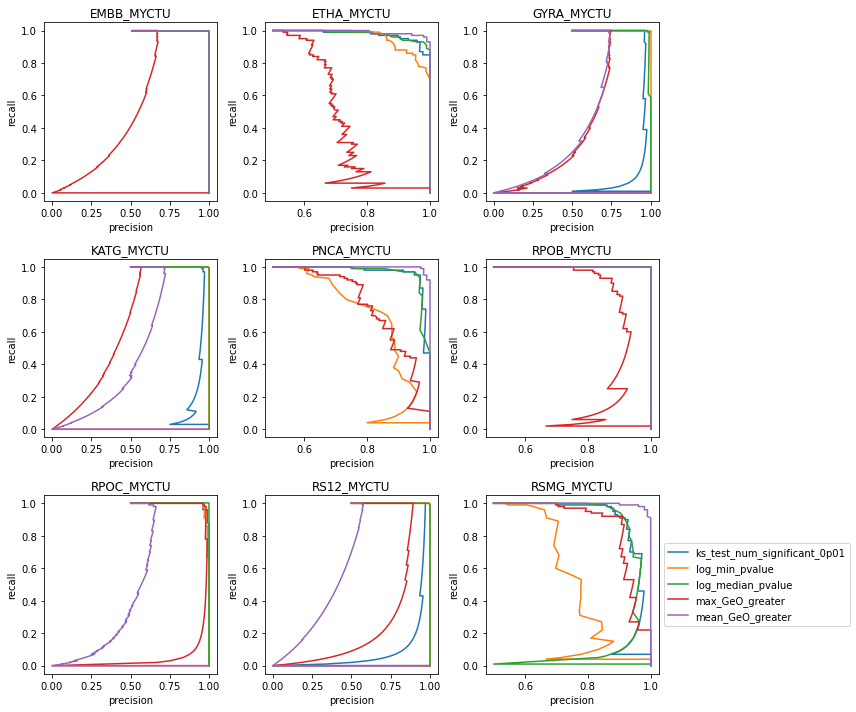

In [14]:
a = np.finfo(np.float64)

### AUCs for each metric
from sklearn.metrics import precision_recall_curve
from sklearn import metrics

fig, axs = plt.subplots(3, 3, figsize=(12, 10))

axs = axs.flatten()



for idx,(protein, group) in enumerate(data.groupby("uid")):

    ax = axs[idx]
    for i, column in  enumerate(['ks_test_num_significant_0p01',  
                                  'log_min_pvalue', 'log_median_pvalue',
                                 'max_GeO_greater', 'mean_GeO_greater']):
        
        precision, recall, thresholds = precision_recall_curve(group.label, group[column])

        ax.plot(precision, recall, label=column)
    ax.set_title(protein)
    
    ax.set_xlabel("precision")
    ax.set_ylabel("recall")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig("figures/per_protein_benchmark.pdf")

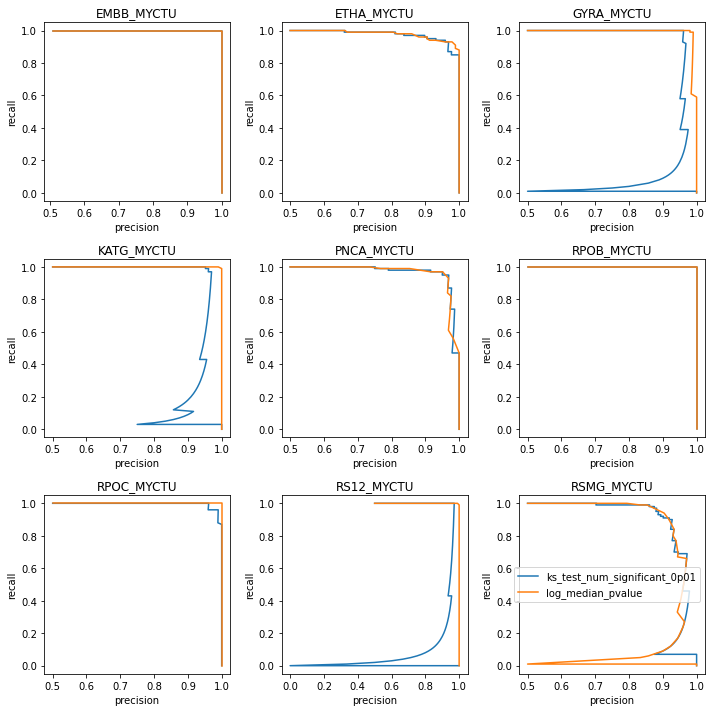

In [15]:
a = np.finfo(np.float64)

### AUCs for each metric
from sklearn.metrics import precision_recall_curve
from sklearn import metrics

fig, axs = plt.subplots(3, 3, figsize=(10, 10))

axs = axs.flatten()



for idx,(protein, group) in enumerate(data.groupby("uid")):

    ax = axs[idx]
    for i, column in  enumerate(['ks_test_num_significant_0p01', 
                                  'log_median_pvalue']):
        
        precision, recall, thresholds = precision_recall_curve(group.label, group[column])

        ax.plot(precision, recall, label=column)
    ax.set_title(protein)
    
    ax.set_xlabel("precision")
    ax.set_ylabel("recall")
plt.legend()
plt.tight_layout()

In [16]:
data.query("uid=='RSMG_MYCTU'").sort_values("ks_test_num_significant_0p01", ascending=False).head(20)

,Unnamed: 0,id,uid,iteration,Entry,rv,label,num_shuffles,max_pvalue,ks_test_num_significant_0p01,...,mean_pvalue,distance_90_percentile,max_GeO_greater,mean_GeO_greater,min_GeO_greater,set,max_GeO,log_max_pvalue,log_median_pvalue,log_min_pvalue
697,697,RSMG_MYCTU_97,RSMG_MYCTU,97,P9WGW9,Rv3919c,1,10000.0,0.333948,9949.0,...,0.000369,7.476749,9986.0,9992.0,15.0,positive,NaN,1.096771,14.434400,31.789914
669,669,RSMG_MYCTU_69,RSMG_MYCTU,69,P9WGW9,Rv3919c,1,10000.0,0.472722,9781.0,...,0.001366,7.569821,9798.0,9978.0,6.0,positive,NaN,0.749248,11.282122,25.475466
640,640,RSMG_MYCTU_40,RSMG_MYCTU,40,P9WGW9,Rv3919c,1,10000.0,0.472722,9735.0,...,0.001343,7.835443,9997.0,9999.0,125.0,positive,NaN,0.749248,11.282122,26.224703
634,634,RSMG_MYCTU_34,RSMG_MYCTU,34,P9WGW9,Rv3919c,1,10000.0,0.472722,9731.0,...,0.001693,9.247381,9444.0,9981.0,58.0,positive,NaN,0.749248,11.282122,25.475466
628,628,RSMG_MYCTU_28,RSMG_MYCTU,28,P9WGW9,Rv3919c,1,10000.0,0.718347,9684.0,...,0.001882,8.357287,9723.0,9994.0,14.0,positive,NaN,0.330802,11.282122,27.757279
658,658,RSMG_MYCTU_58,RSMG_MYCTU,58,P9WGW9,Rv3919c,1,10000.0,0.798323,9661.0,...,0.002269,7.603582,10000.0,9989.0,55.0,positive,NaN,0.225241,10.315586,21.897987
649,649,RSMG_MYCTU_49,RSMG_MYCTU,49,P9WGW9,Rv3919c,1,10000.0,0.634695,9629.0,...,0.002192,7.499215,9861.0,10000.0,468.0,positive,NaN,0.454610,8.944013,21.215930
1516,616,RSMG_MYCTU_16,RSMG_MYCTU,16,P9WGW9,Rv3919c,0,10000.0,0.869422,9583.0,...,0.003364,9.781272,9744.0,3716.0,18.0,negative,4.512338,0.139926,12.290622,24.010866
607,607,RSMG_MYCTU_7,RSMG_MYCTU,7,P9WGW9,Rv3919c,1,10000.0,0.551745,9514.0,...,0.002702,6.995913,9993.0,10000.0,6511.0,positive,NaN,0.594669,10.793622,35.226390
670,670,RSMG_MYCTU_70,RSMG_MYCTU,70,P9WGW9,Rv3919c,1,10000.0,0.551745,9459.0,...,0.003042,7.973799,9939.0,9980.0,70.0,positive,NaN,0.594669,8.944013,24.737536


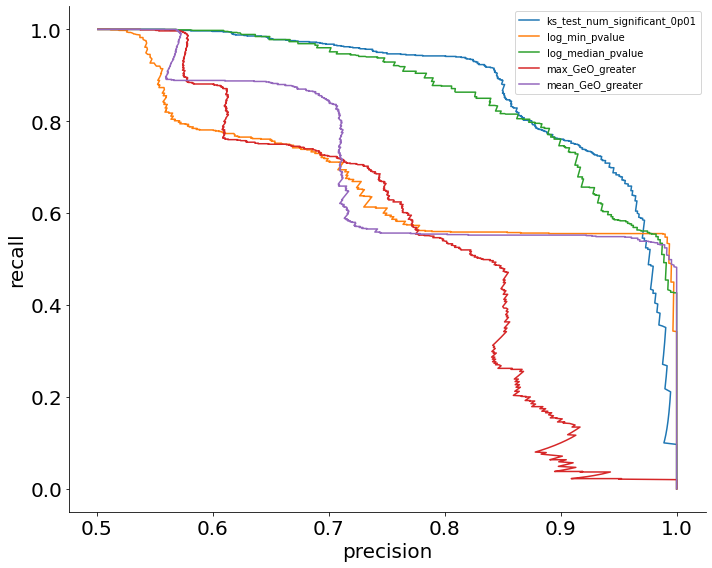

In [17]:
a = np.finfo(np.float64)

### AUCs for each metric
from sklearn.metrics import precision_recall_curve
from sklearn import metrics

fig = plt.figure(figsize=(10,8))
ax = fig.gca()

for i, column in  enumerate(['ks_test_num_significant_0p01',
                                  'log_min_pvalue', 'log_median_pvalue',
                                 'max_GeO_greater', 'mean_GeO_greater']):

    precision, recall, thresholds = precision_recall_curve(data.label, data[column])

    ax.plot(precision, recall, label=column)
    

ax.set_xlabel("precision",fontsize=20)
ax.set_ylabel("recall", fontsize=20)
sns.despine()
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend()
plt.tight_layout()
plt.savefig("figures/all_protein_benchmark.pdf")

In [18]:
!pwd

/n/data1/hms/dbmi/farhat/anna/structure_annotation/2024_11_13_GeO


ks_test_num_significant_0p01
recall at 0.95 precision 0.6833333333333333
precision 0.9505409582689336
threshold 9267.0


log_median_pvalue
recall at 0.95 precision 0.5844444444444444
precision 0.9511754068716094
threshold 19.76478145066588




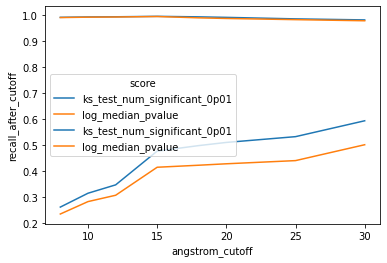

In [19]:
# Based on the above plot, we want to examine four in more detail

valid_scores = [ 'ks_test_num_significant_0p01', 
                                 
                                 'log_median_pvalue']
cutoffs = [8, 10, 12, 15, 18, 20, 25, 30]

_d = []

precision_threshold = 0.95

for score in valid_scores: 
    print(score)
    precision, recall, threshold = precision_recall_curve(data.label, data[score])
    index = np.where(precision > precision_threshold)[0][0]
    
    data[score] = data[score].astype(float)
    
    print(f"recall at {precision_threshold} precision", recall[index])
    print("precision", precision[index])
    print("threshold", threshold[index])
    print()
    
    _threshold = float(threshold[index])
    above_thresh = data.loc[data[score] >_threshold, :]

    for cutoff in cutoffs: 
        #print(cutoff)
        above_cutoff = above_thresh.query("distance_top_pair < @cutoff")
        
        if len(above_cutoff) > 0:

            prec = len(above_cutoff.query("label==1"))/len(above_cutoff)
            rec = len(above_cutoff.query("label==1"))/len(data.query("label==1"))
            
        else:
            prec = np.nan
            rec = np.nan
        
#         print("precision above cutoff", prec)
        
#         print("recall above cutoff", rec)
        
#         for cutoff2 in cutoffs: 
#             #print(cutoff)
#             above_cutoff2 = above_cutoff1.query("distance_top_pair < @cutoff2")

#             prec = len(above_cutoff2.query("label==1"))/len(above_cutoff2)
#             rec = len(above_cutoff2.query("label==1"))/len(data.query("label==1"))

#             print("precision above cutoff", prec)

#             print("recall above cutoff", rec)

        _d.append([score, precision[index], recall[index], threshold[index], cutoff,  prec, rec])
        
    print()
filtering_data = pd.DataFrame(_d, columns=["score", "precision", "recall", "threshold", "angstrom_cutoff", "prec_after_cutoff", "recall_after_cutoff"])

sns.lineplot(data=filtering_data, x="angstrom_cutoff", y="recall_after_cutoff", hue='score')
plt.savefig("figures/recall_per_angstrom_cutoff.pdf")
sns.lineplot(data=filtering_data, x="angstrom_cutoff", y="prec_after_cutoff", hue='score')
plt.show("figures/precision_per_angstrom_cutoff.pdf")

In [47]:
data

,Unnamed: 0,id,uid,iteration,Entry,rv,label,num_shuffles,max_pvalue,ks_test_num_significant_0p01,...,mean_pvalue,distance_90_percentile,max_GeO_greater,mean_GeO_greater,min_GeO_greater,set,max_GeO,log_max_pvalue,log_median_pvalue,log_min_pvalue
43,43,RPOB_MYCTU_43,RPOB_MYCTU,43,P9WGY9,Rv0667,1,10000.0,0.619650,9909.0,...,0.000843,14.247963,9104.0,10000.0,9508.0,positive,NaN,0.478601,126.533517,710.258404
20,20,RPOB_MYCTU_20,RPOB_MYCTU,20,P9WGY9,Rv0667,1,10000.0,0.391040,9937.0,...,0.000429,14.297007,8622.0,10000.0,9750.0,positive,NaN,0.938945,111.868125,741.549700
0,0,RPOB_MYCTU_0,RPOB_MYCTU,0,P9WGY9,Rv0667,1,10000.0,0.619650,9932.0,...,0.000553,14.391684,8712.0,10000.0,9974.0,positive,NaN,0.478601,144.358797,704.496729
78,78,RPOB_MYCTU_78,RPOB_MYCTU,78,P9WGY9,Rv0667,1,10000.0,0.584578,9921.0,...,0.000613,14.426705,9183.0,10000.0,9879.0,positive,NaN,0.536866,123.117101,719.940502
70,70,RPOB_MYCTU_70,RPOB_MYCTU,70,P9WGY9,Rv0667,1,10000.0,0.550012,9932.0,...,0.000507,14.219678,8629.0,10000.0,9523.0,positive,NaN,0.597815,123.796446,743.746925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1122,222,KATG_MYCTU_22,KATG_MYCTU,22,P9WIE5,Rv1908c,0,10000.0,0.999190,6528.0,...,0.070546,36.717615,869.0,725.0,5279.0,negative,2.833482,0.000810,6.963205,49.217733
1260,360,PNCA_MYCTU_60,PNCA_MYCTU,60,I6XD65,Rv2043c,0,10000.0,0.999427,468.0,...,0.380129,14.479487,6392.0,4920.0,4627.0,negative,3.114421,0.000573,1.061327,12.952034
1722,822,RS12_MYCTU_22,RS12_MYCTU,22,P9WH63,Rv0682,0,10000.0,0.999962,1122.0,...,0.314346,18.911106,5385.0,2959.0,9059.0,negative,3.536889,0.000038,1.404349,26.880197
1790,890,RS12_MYCTU_90,RS12_MYCTU,90,P9WH63,Rv0682,0,10000.0,0.999962,1217.0,...,0.367197,9.666473,2691.0,5990.0,8508.0,negative,2.691496,0.000038,1.151971,28.938380


## Now, investigate adding a second criterion

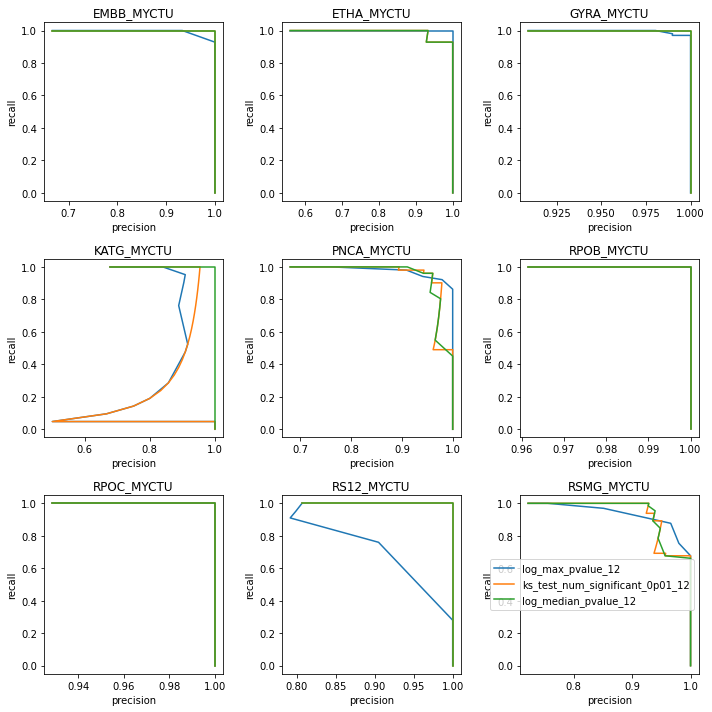

In [13]:
### AUCs for each metric
from sklearn.metrics import precision_recall_curve
from sklearn import metrics

fig, axs = plt.subplots(3, 3, figsize=(10, 10))

axs = axs.flatten()



for idx,(protein, group) in enumerate(data.groupby("uid")):

    ax = axs[idx]
    for i, column in  enumerate([ 'ks_test_num_significant_0p01', 'log_median_pvalue']):
        
        for i,cutoff in enumerate([ 12]):
            
            x = group.query("distance_top_pair < @cutoff")
            
            if len(x) == 0:
                continue
        
            precision, recall, thresholds = precision_recall_curve(x.label, x[column])

            ax.plot(precision, recall, label=column+"_" + str(cutoff))
    ax.set_title(protein)
    
    ax.set_xlabel("precision")
    ax.set_ylabel("recall")
plt.legend()
plt.tight_layout()

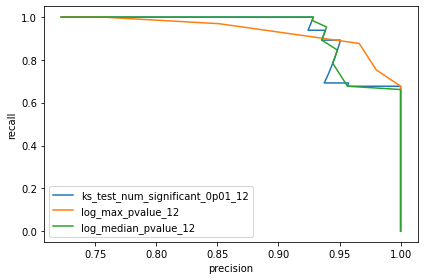

In [15]:
a = np.finfo(np.float64)

### AUCs for each metric
from sklearn.metrics import precision_recall_curve
from sklearn import metrics

fig, ax = plt.subplots()

for i, column in  enumerate(['ks_test_num_significant_0p01',  'log_median_pvalue']):

        for i,cutoff in enumerate([12]):
            
            x = group.query("distance_top_pair < @cutoff")
            precision, recall, thresholds = precision_recall_curve(x.label, x[column])

            ax.plot(precision, recall, label=column+"_" + str(cutoff))
    

ax.set_xlabel("precision")
ax.set_ylabel("recall")
plt.legend()
plt.tight_layout()

In [50]:
data = pd.read_csv("summary_data/controls_10000iterations_pvalues_NOTPAIRED.csv", index_col=0)

for column in [ "selected_pvalue", "median_pvalue", "min_pvalue"]:

    data = data.dropna(subset=[column])
    data["log_" + column] = [-np.log(x) for x in data[column]]
    

data = data.dropna(subset=['log_median_pvalue'])
precision, recall, thresholds = precision_recall_curve(data.label, data['log_median_pvalue'])

threshold_index = np.where(recall > 0.8)[0][-1]

print("At 80% recall, model achieves", precision[threshold_index], "precision")
print("score threshold:", thresholds[threshold_index])

At 80% recall, model achieves 0.8728813559322034 precision
score threshold: 10.332939454457076


In [51]:
data = data.dropna(subset=['log_median_pvalue'])
precision, recall, thresholds = precision_recall_curve(data.label, data['log_median_pvalue'])

threshold_index = np.where(precision > 0.90)[0][0]

print("At 90% precision, model achieves", recall[threshold_index], "recall")
print("score threshold:", thresholds[threshold_index])

At 90% precision, model achieves 0.7611111111111111 recall
score threshold: 11.941848047524221


In [52]:

dataf = data.query("distance_top_pair < 8")

data_sig = data.query("log_median_pvalue > @thresholds[@threshold_index]")
dataf_sig = dataf.query("log_median_pvalue > @thresholds[@threshold_index]")

print(len(data_sig.query("set=='positive'")), len(data_sig.query("set=='negative'")))
print(len(dataf_sig.query("set=='positive'")), len(dataf_sig.query("set=='negative'")))



674 76
306 4


In [53]:
!pwd

/n/data1/hms/dbmi/farhat/anna/structure_annotation/2024_11_13_GeO
